### CSC 8222 Network Security (Spring 2025) ###
### Assignment 2: Explore Explainable AI_SHAP
Name: Pranjal Vijaysing Patil               Panther Id: 002851130

### 1) Using SHAP to analyze feature importance in machine learning decisions : California Housing Dataset ###

In [1]:
#! pip install shap

In [1]:
import tensorflow as tf

ImportError: cannot import name 'float8_e4m3b11fnuz' from 'tensorflow.python.framework.dtypes' (C:\Users\Pranjal\anaconda3\Lib\site-packages\tensorflow\python\framework\dtypes.py)

In [ ]:
print(tf.__version__)

In [64]:
import shap
import xgboost
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


In [66]:
#Loading the sample dataset
X,y = shap.datasets.california()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [67]:
#Training the model
model = xgboost.XGBRegressor()

In [68]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [69]:
#Predicting the model
y_pred = model.predict(X_test)

In [70]:
#Calculating the mean squared error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")


Mean Squared Error: 0.2078329679717226


In [71]:
#Explaining the model
explainer = shap.Explainer(model=model,masker = X_train)

In [72]:
explainer.__class__

shap.explainers._tree.TreeExplainer

In [73]:
shap_values = explainer(X_test)

 93%|=================== | 3822/4128 [00:13<00:01]       

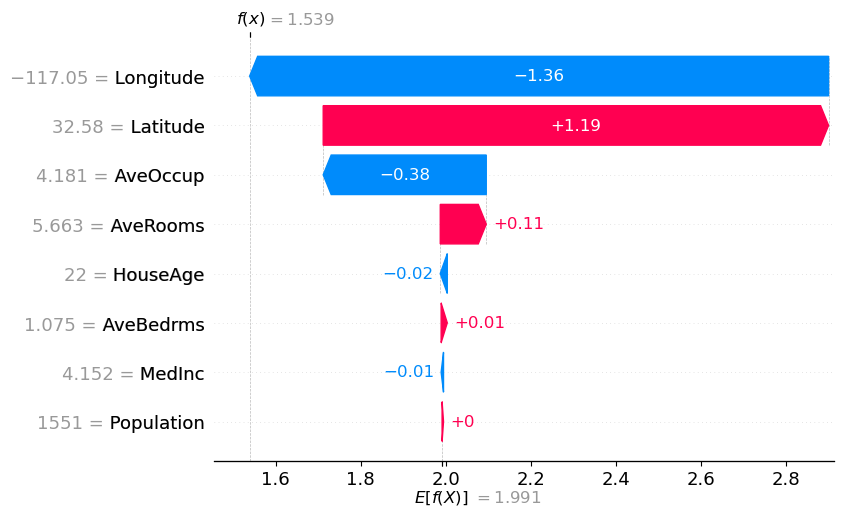

In [74]:
#Local Explanations
#Visualizing the shapely values for the first instance of the test dataset using waterfall model
#the waterfall plot shows how we get from shap_values.base_values to model.predict(X_test)[0]
shap.plots.waterfall(shap_values[0])

In [75]:
#Force plot
#loading the javascript library to plot the force plot
shap.initjs()

In [76]:
#plotting the force plot for the first instance of the test dataset using shapely values
shap.plots.force(shap_values[0])


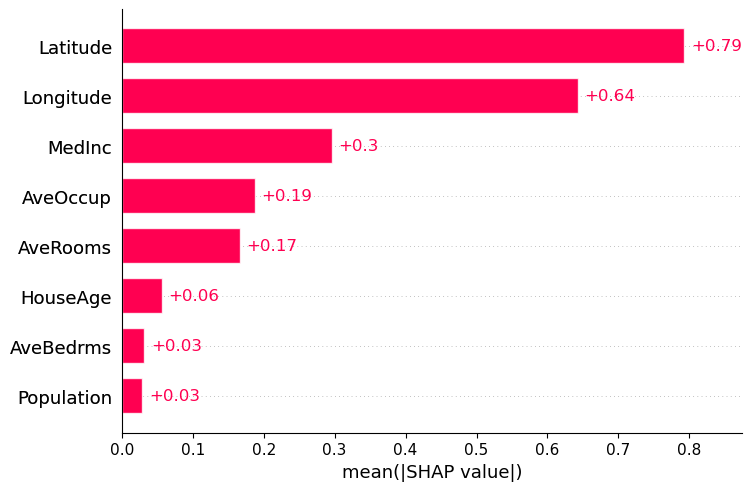

In [77]:
#Global Explanations
#Describe the overall behaviour of the model using bar plots
shap.plots.bar(shap_values)

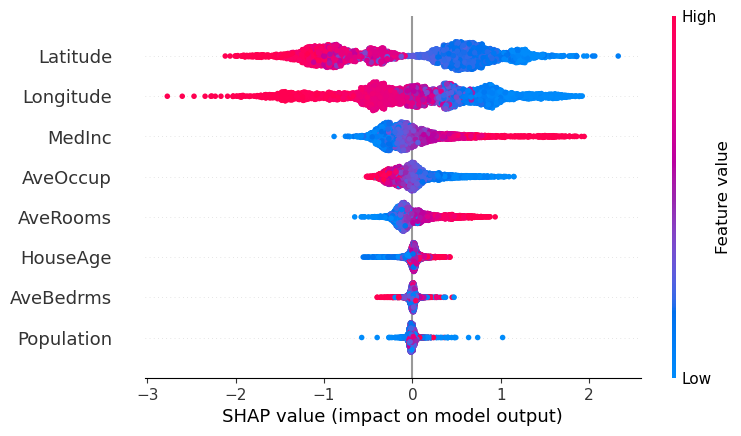

In [78]:
shap.plots.beeswarm(shap_values)

In [79]:
#Force plot for shapely values of the entire dataset
shap.plots.force(shap_values[0:100])

### 2) Try a different dataset ###

### Breast Cancer Dataset  Analysis using Shapely Values ###

In [80]:
import sklearn.datasets
X, y = sklearn.datasets.load_breast_cancer(return_X_y=True)

In [81]:
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X, y, test_size=0.2, random_state=0)

In [82]:
A = xgboost.XGBClassifier()
A.fit(X_train_A, y_train_A)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [83]:
y_pred_A = A.predict(X_test_A)

In [84]:
#Calculating the mean squared error
mse_A = mean_squared_error(y_test_A, y_pred_A)
print(f"Mean Squared error for Brest Cancel Dataset analysis using XGBoost: {mse_A}")

Mean Squared error for Brest Cancel Dataset analysis using XGBoost: 0.043859649122807015


In [85]:
#Explaining the model
explainer_A =shap.Explainer(model=A, masker = X_train_A)


In [86]:
explainer_A.__class__

shap.explainers._tree.TreeExplainer

In [87]:
shap_values_A = explainer_A(X_test_A)

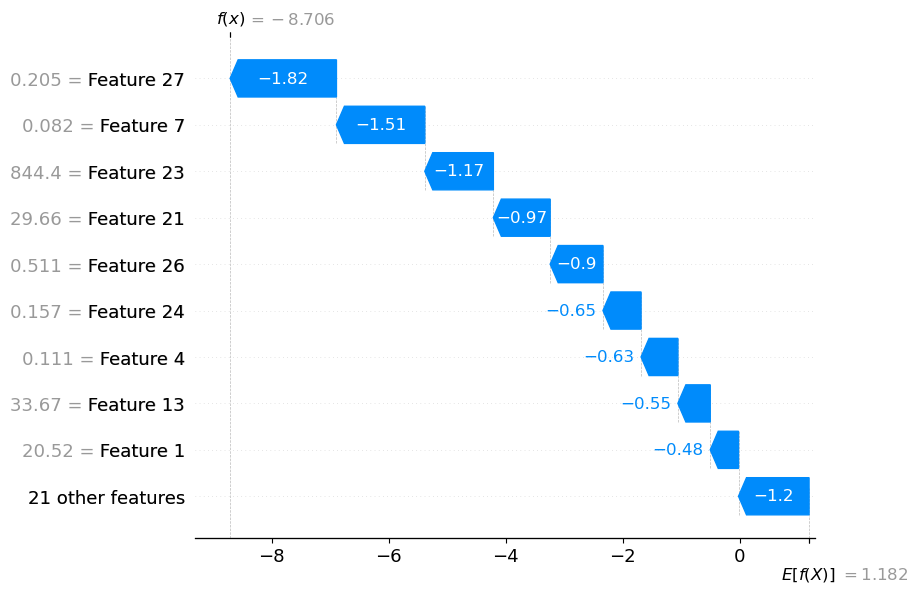

In [88]:
#Local Explanations
#Visualizing the shapely values for the first instance of the test dataset using waterfall model
#the waterfall plot shows how we get from shap_values.base_values to model.predict(X_test)[0]
shap.plots.waterfall(shap_values_A[0])

In [89]:
#Force plot
#loading the javascript library to plot the force plot
shap.initjs()

In [90]:
#plotting the force plot for the first instance of the test dataset using shapely values
shap.plots.force(shap_values_A[0])

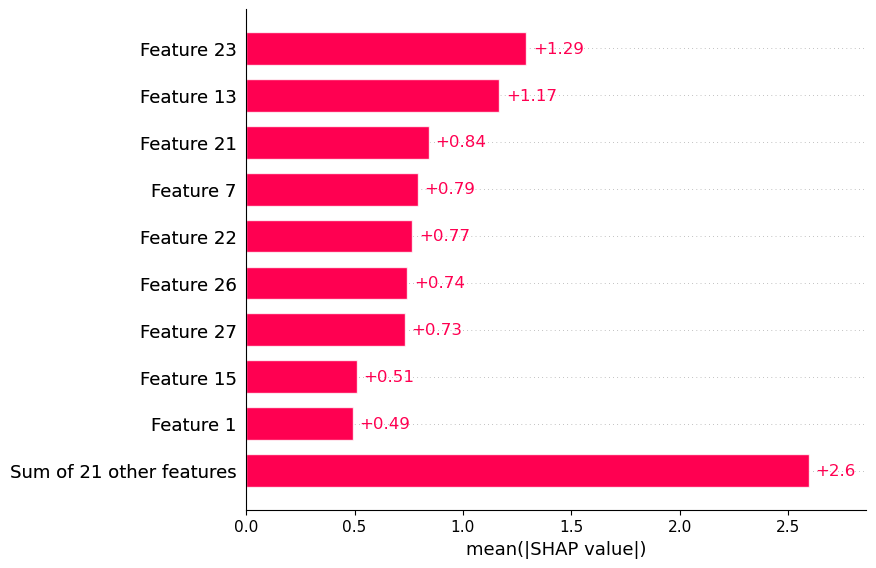

In [91]:
#Global Explanations
#Describe the overall behaviour of the model using bar plots
shap.plots.bar(shap_values_A)

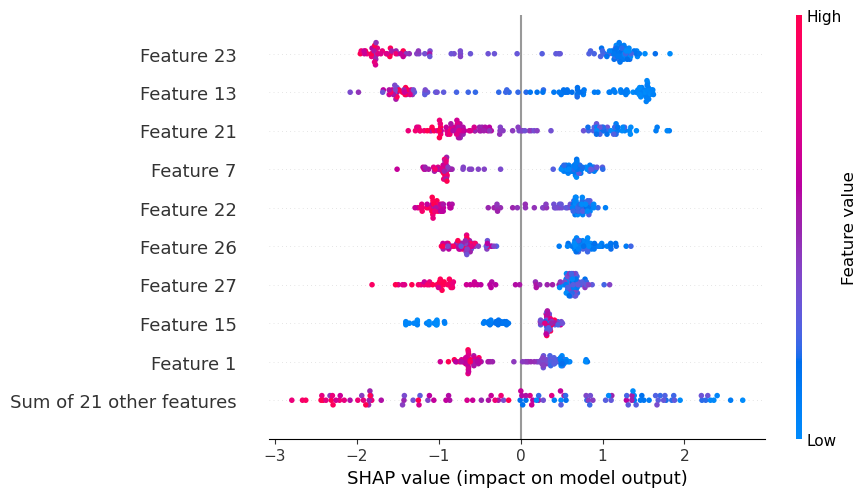

In [92]:
shap.plots.beeswarm(shap_values_A)

In [93]:
#Force plot for shapely values of the entire dataset
shap.plots.force(shap_values_A[0:100])

### 3) Try a different machine learning model ###

### RandomForest Classifier for Breast Cancer Dataset ###

In [94]:
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X, y, test_size=0.2, random_state=0)

In [95]:
from sklearn.ensemble import RandomForestClassifier
B = RandomForestClassifier()
B.fit(X_train_B, y_train_B)

RandomForestClassifier()

In [96]:
y_pred_B = B.predict(X_test_B)

In [97]:
#Calculating the mean squared error
mse_B = mean_squared_error(y_test_B, y_pred_B)
print(f"Mean Squared error for Brest Cancel Dataset analysis using Random Forest Classifier: {mse_B}")

Mean Squared error for Brest Cancel Dataset analysis using Random Forest Classifier: 0.03508771929824561


In [98]:
#Explaining the model
explainer_B =shap.Explainer(model= B, masker = X_train_B)

In [101]:
shap_values_B = explainer_B(X_test_B)

Local Explanations : waterfall plot  for first instance with positive class =1

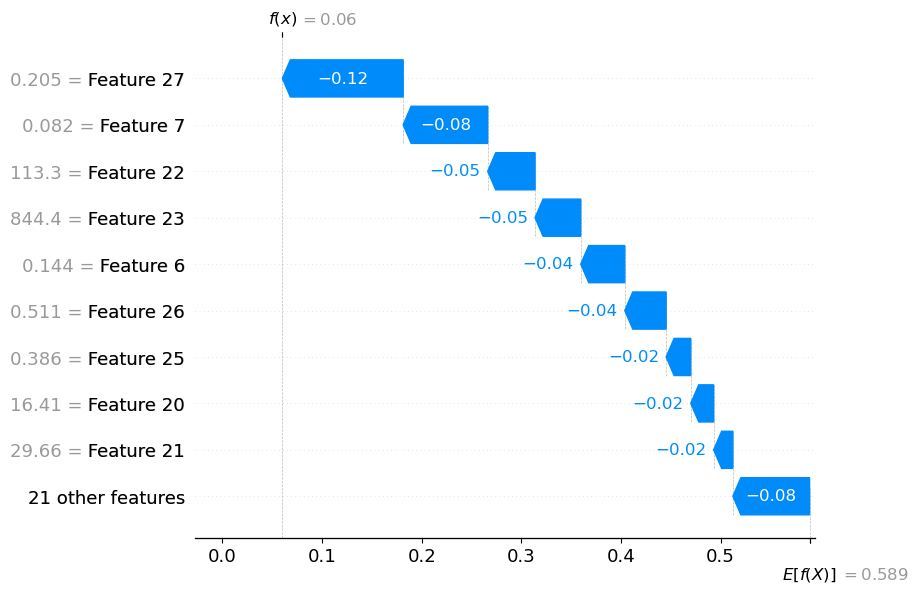

In [102]:
shap.plots.waterfall(shap_values_B[0:1,:,1][0])

Local Explanations : waterfall plot  for first instance with positive class =0

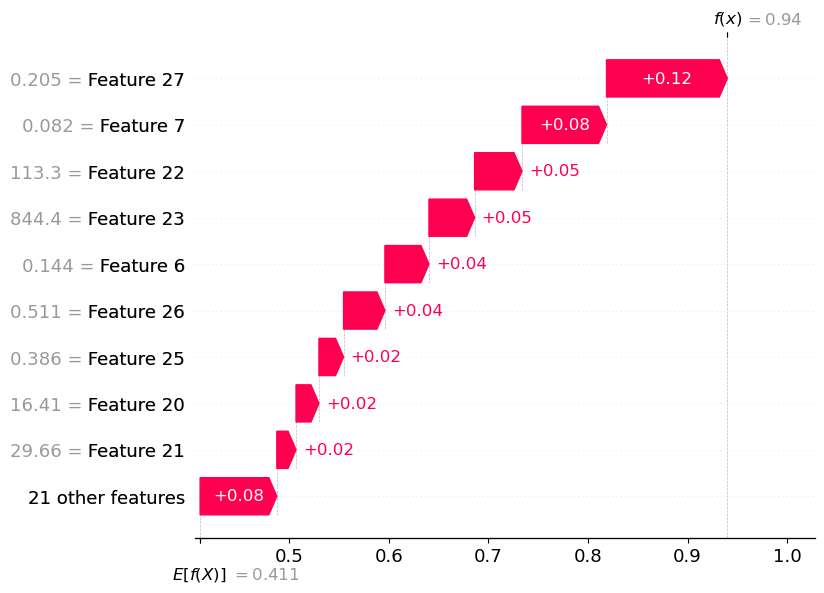

In [103]:
shap.plots.waterfall(shap_values_B[0:1,:,0][0])

Global Explanations : bar plot for whole dataset

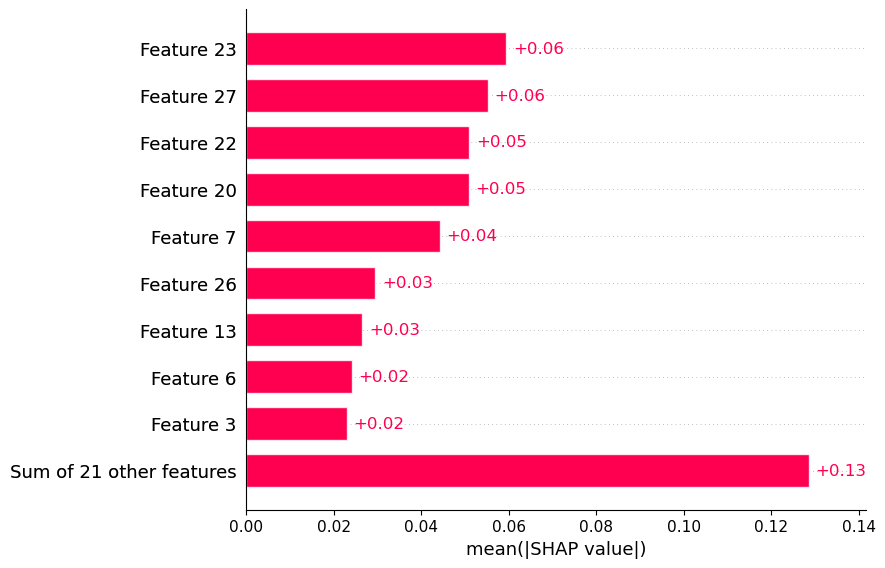

In [104]:
shap.plots.bar(shap_values_B[:,:,1])

Global Explanations : beeswarm plot for all instances with positive class =1

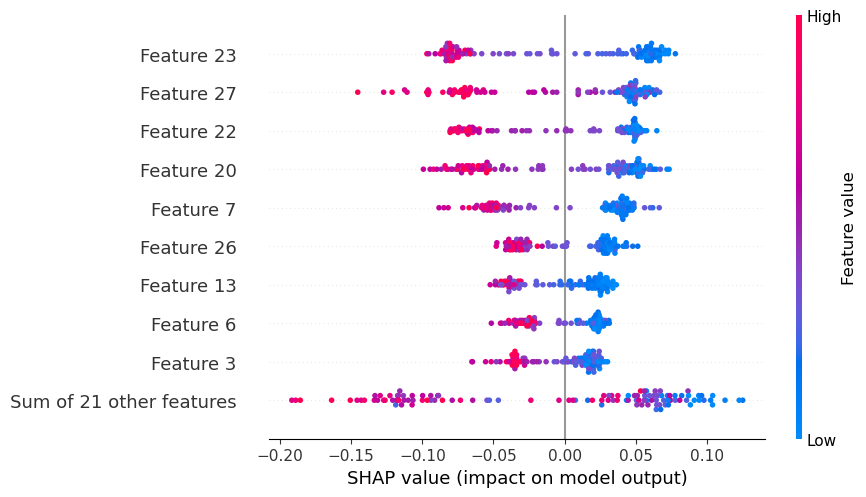

In [105]:
shap.plots.beeswarm(shap_values_B[:,:,1])

In [106]:
#Force plot for shapely values of the entire dataset for negative class=0
shap.plots.force(shap_values_B[0:100,:,0])

### 4) compare SHAP's outcome on A and B ###

a) Look at the SHAP values of the first instance in your training dataset on A and B. Do
they agree on the importance of features?

In [107]:
#SHAP values for the first instance in the training dataset for A
shap_values_A[0]

.values =
array([ 0.        , -0.48292167,  0.        ,  0.        , -0.62887906,
       -0.05431625, -0.10925968, -1.50921985, -0.03064622,  0.00906417,
       -0.0353448 ,  0.        , -0.03206201, -0.5528825 , -0.00776337,
        0.34020947,  0.0641423 , -0.11251912, -0.21498946,  0.        ,
       -0.14128268, -0.97080138, -0.39602698, -1.17098273, -0.65056668,
       -0.12866248, -0.90176349, -1.81530112, -0.34554303, -0.00969183])

.base_values =
1.1815354564359268

.data =
array([1.340e+01, 2.052e+01, 8.864e+01, 5.567e+02, 1.106e-01, 1.469e-01,
       1.445e-01, 8.172e-02, 2.116e-01, 7.325e-02, 3.906e-01, 9.306e-01,
       3.093e+00, 3.367e+01, 5.414e-03, 2.265e-02, 3.452e-02, 1.334e-02,
       1.705e-02, 4.005e-03, 1.641e+01, 2.966e+01, 1.133e+02, 8.444e+02,
       1.574e-01, 3.856e-01, 5.106e-01, 2.051e-01, 3.585e-01, 1.109e-01])

In [108]:
#SHAP values for the first instance in the training dataset for B
shap_values_B[0:1,:,1]

.values =
array([[ 0.00101643, -0.00704536, -0.0059369 , -0.00071821, -0.01392333,
        -0.00242667, -0.04420071, -0.08486357, -0.00185667,  0.0041394 ,
        -0.00167714,  0.00103571, -0.00262964, -0.00331476,  0.00130548,
        -0.00167333, -0.00326143,  0.00042762, -0.00122643, -0.00174   ,
        -0.02299667, -0.01928881, -0.04754131, -0.04584786, -0.01752607,
        -0.02470762, -0.04151155, -0.1212525 , -0.01786524, -0.00209286]])

.base_values =
array([0.5893])

.data =
array([[1.340e+01, 2.052e+01, 8.864e+01, 5.567e+02, 1.106e-01, 1.469e-01,
        1.445e-01, 8.172e-02, 2.116e-01, 7.325e-02, 3.906e-01, 9.306e-01,
        3.093e+00, 3.367e+01, 5.414e-03, 2.265e-02, 3.452e-02, 1.334e-02,
        1.705e-02, 4.005e-03, 1.641e+01, 2.966e+01, 1.133e+02, 8.444e+02,
        1.574e-01, 3.856e-01, 5.106e-01, 2.051e-01, 3.585e-01, 1.109e-01]])

Observation: The SHAP values for the first instance of dataset on A and B do not agree on feature importance.

b) Look at the mean(|SHAP value|) on bar graph of A and B. Do they agree with each
other?


Observation: The mean(|SHAP value|) on bar graph of A and B also do not agree with each other as well

c)If A’s explanation and B’s explanation do not agree with each other, what is the
possible reason?


Answer: The reason lies in the way both the algorithms works.
Model A uses XGBoost classifier which is a Boosting Ensemble algorithm. It implements Sequential ensemble learning with trees correcting the errors of previous trees. Whereas the RandomForestClassifier uses Bagging (Bootstrap Aggregration). It constructs several decision trees and combines them. It also implements subsampling while constructing the trees. Because of this difference in the algorithms, the emphasis on feature importance also varies. XGBoost SHAP values emphasises the features which are helpful in the later stages of the boosting process , which were also used to correct the errors of previous trees. Whereas the feature importance emphasis in RandomForestClassifier is independent in every other tree, during the ensemble process.

d)Given your observation in step 4), in your opinion, what potential challenges we may
have for using SHAP in real-world applications?

Answer: From the above observation, we can say that SHAP values are sensitive to the underline chosen model and give varying feature importance. Making it crucial to select the correct model for the correct scenarios.